# Aberrated Aperture Probe

Compare Gaussian Taylor beam propagation against a Fresnel propagator while sampling new aberration coefficients on each run.


## Setup

Configure JAX, import the required modules, and create a time-based seed so the notebook produces different aberrations every run.


In [1]:
from temgym_core.utils import AngularSpectrumPropagator, FresnelPropagator, energy2wavelength, zero_phase
import os
import time

os.environ["JAX_ENABLE_X64"] = "1"

%matplotlib widget

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.components import Detector
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.gaussian import make_gaussian_plane_wave_round_aperture
from temgym_core.gaussian_taylor import KrivanekLens, SigmoidAperture, run_to_end
from temgym_core.utils import FresnelPropagator, energy2wavelength, zero_phase

jax.config.update("jax_enable_x64", True)

seed = np.uint32(time.time_ns() & 0xFFFFFFFF)
key = jax.random.PRNGKey(seed)

print(f"Simulation seed: {int(seed)}")


Simulation seed: 531225487


## Simulation Parameters

Define the microscope geometry, sampling grids, and helpers shared across the beam and Fresnel models.


In [2]:
voltage = 300_000  # V
wavelength = energy2wavelength(voltage)
k0 = 2 * jnp.pi / wavelength

aperture_radius = 0.25e-6  # m
window_width = 2e-6  # m
Nx = Ny = 512
pixel_size = window_width / Nx
focal_length = 5e-3  # m

input_grid = Detector(
    z=0.0,
    pixel_size=(pixel_size, pixel_size),
    shape=(Ny, Nx),
)
output_grid = Detector(
    z=focal_length * 2,
    pixel_size=(pixel_size, pixel_size),
    shape=(Ny, Nx),
)

aperture = SigmoidAperture(radius=aperture_radius, sharpness=1000.0, z=0.0, t_outside=0.0)

idx_x = Nx // 2
idx_y = Ny // 2
x_coords, y_coords = output_grid.coords_1d


def center_zero_phase(field):
    """Anchor the global phase for easier visual comparison."""
    return zero_phase(field, idx_x, idx_y)


def field_from_rays(rays, grid):
    field = evaluate_gaussians_gpu_kernel_wrapper(rays, grid).block_until_ready()
    return center_zero_phase(field)


## Sample Aberration Coefficients

Split the random key to draw aberration parameters and assemble the corresponding lens model.


In [3]:
key, coeff_key = jax.random.split(key)
random_vals = jax.random.uniform(coeff_key, (8,), minval=-1.0, maxval=1.0)
r0, r1, r2, r3, r4, r5, r6, r7 = map(float, random_vals.tolist())

coeffs = KrivanekCoeffs(
    C30=8 * r0,
    C21=8 * r1,
    phi21=2 * jnp.pi * r2,
    C23=8 * r3,
    phi23=2 * jnp.pi * r4,
    C32=8 * r5,
    phi32=jnp.pi * r6,
    C43=8 * r7,
    phi43=jnp.pi * r0,
)

phase_plate = KrivanekLens(focal_length=focal_length, z=focal_length, coeffs=coeffs)
phase_mask = jax.vmap(phase_plate.opl_shift)(output_grid.coords).reshape(output_grid.shape)

w0 = 2e-9  # beam waist (m)
rays_in, wavelength, k0 = make_gaussian_plane_wave_round_aperture(
    voltage=voltage,
    aperture_radius=aperture.radius,
    waist_radius=w0,
    num_rays=200_000,
    normalization="flux",
)
rays_in = rays_in.to_vector()

run_to_end_jit = jax.jit(run_to_end)
run_to_end_vmapped = jax.jit(
    jax.vmap(run_to_end_jit, in_axes=(0, None)),
    static_argnums=(1,),
)


## Propagate Beams

Propagate the Gaussian rays and compute matching Fresnel-field snapshots at each plane.


In [4]:
rays_after_input = run_to_end_vmapped(rays_in, (aperture,))
gaussian_field_at_input = field_from_rays(rays_after_input, input_grid)

rays_after_lens = run_to_end_vmapped(rays_after_input, (phase_plate,))
gaussian_field_after_lens = field_from_rays(rays_after_lens, input_grid)

rays_after_free_space = run_to_end_vmapped(rays_after_lens, (output_grid,))
gaussian_field_at_back_focal_plane = field_from_rays(rays_after_free_space, output_grid)

fresnel_field_at_input = gaussian_field_at_input
fresnel_field_before_lens = center_zero_phase(
    FresnelPropagator(gaussian_field_at_input, window_width, wavelength, focal_length)
)
fresnel_field_after_lens = center_zero_phase(
    fresnel_field_before_lens * jnp.exp(1j * k0 * phase_mask)
)
fresnel_field_at_back_focal_plane = center_zero_phase(
    FresnelPropagator(fresnel_field_after_lens, window_width, wavelength, focal_length)
)

angular_field_at_input = gaussian_field_at_input
angular_field_before_lens = center_zero_phase(
    AngularSpectrumPropagator(gaussian_field_at_input, window_width, wavelength, focal_length)
)
angular_field_after_lens = center_zero_phase(
    angular_field_before_lens * jnp.exp(1j * k0 * phase_mask)
)
angular_field_at_back_focal_plane = center_zero_phase(
    AngularSpectrumPropagator(angular_field_after_lens, window_width, wavelength, focal_length)
)


## Visualise Fields

Compare amplitudes and phases for the Gaussian and Fresnel solutions at the input, lens, and output planes.


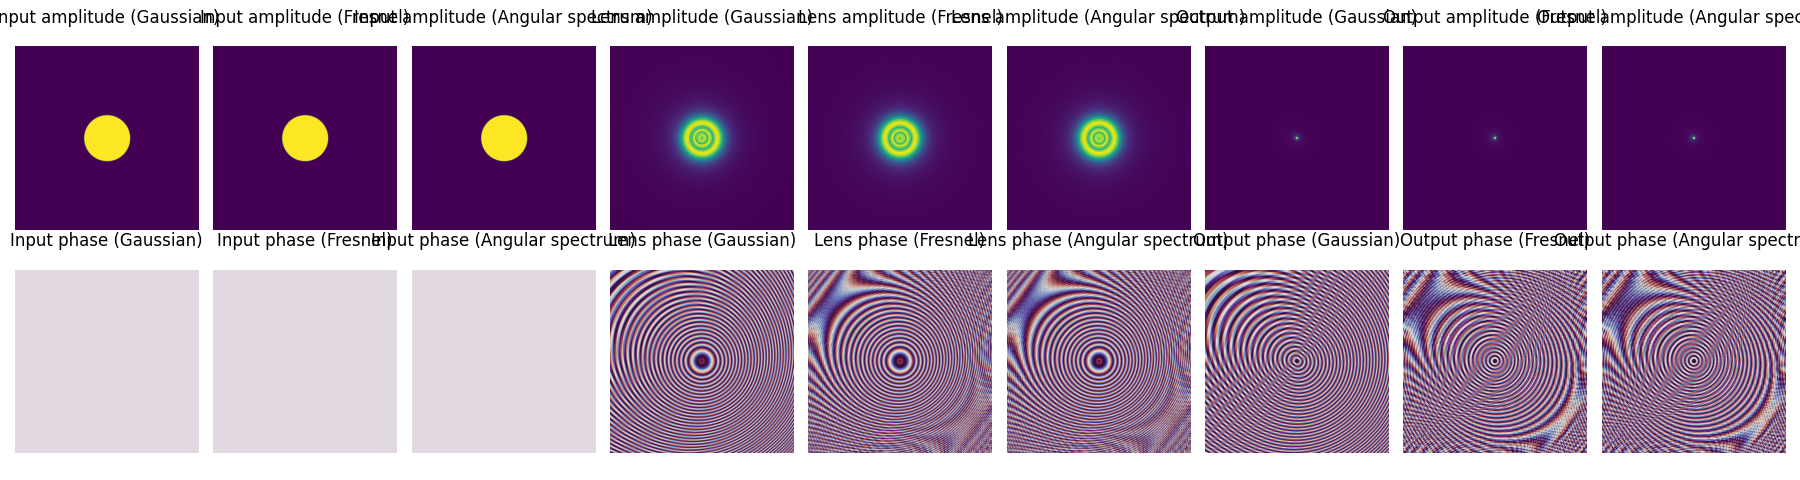

In [5]:
def show_field(ax, data, extent, title, cmap=None):
    im = ax.imshow(data, extent=extent, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    return im

fig, axes = plt.subplots(2, 9, figsize=(18, 4.8))
field_summaries = [
    ("Input", gaussian_field_at_input, fresnel_field_at_input, angular_field_at_input, input_grid.extent),
    ("Lens", gaussian_field_after_lens, fresnel_field_after_lens, angular_field_after_lens, input_grid.extent),
    ("Output", gaussian_field_at_back_focal_plane, fresnel_field_at_back_focal_plane, angular_field_at_back_focal_plane, output_grid.extent),
]
method_labels = ["Gaussian", "Fresnel", "Angular spectrum"]

for col, (label, gaussian_field, fresnel_field, angular_field, extent) in enumerate(field_summaries):
    for method_idx, (method_label, field) in enumerate(zip(method_labels, (gaussian_field, fresnel_field, angular_field))):
        ax_col = 3 * col + method_idx
        show_field(axes[0, ax_col], np.abs(field), extent, f"{label} amplitude ({method_label})")
        show_field(axes[1, ax_col], np.angle(field), extent, f"{label} phase ({method_label})", cmap="twilight")

plt.tight_layout()
plt.show()


## Output Cross-Section

Inspect the amplitude profile along the central horizontal cut in the back focal plane.


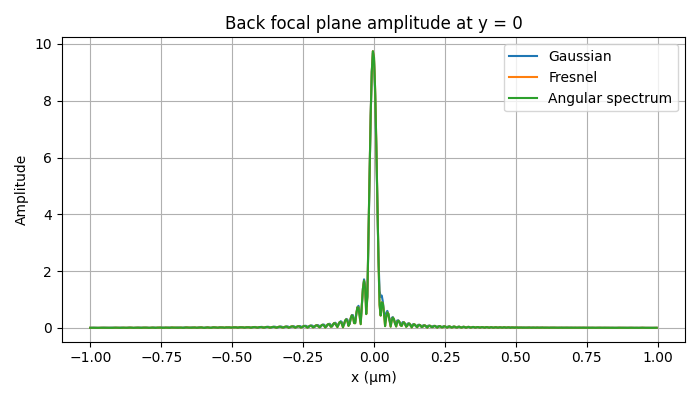

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
idx_y_center = Ny // 2

gaussian_amp_cross = np.abs(gaussian_field_at_back_focal_plane[idx_y_center, :])
fresnel_amp_cross = np.abs(fresnel_field_at_back_focal_plane[idx_y_center, :])
angular_amp_cross = np.abs(angular_field_at_back_focal_plane[idx_y_center, :])

ax.plot(x_coords * 1e6, gaussian_amp_cross, label="Gaussian")
ax.plot(x_coords * 1e6, fresnel_amp_cross, label="Fresnel")
ax.plot(x_coords * 1e6, angular_amp_cross, label="Angular spectrum")
ax.set_xlabel("x (µm)")
ax.set_ylabel("Amplitude")
ax.set_title("Back focal plane amplitude at y = 0")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


## 3D Ray Diagram

Visualise the Gaussian rays leaving the lens and striking the back focal plane together with the resulting intensity map.


In [7]:
import numpy as np
import plotly.graph_objects as go

origin_um = float(np.asarray(rays_after_lens.z).mean()) * 1e6
lens_xyz = np.column_stack([
    np.asarray(rays_after_lens.x) * 1e6,
    np.asarray(rays_after_lens.y) * 1e6,
    np.asarray(rays_after_lens.z) * 1e6 - origin_um,
])
out_xyz = np.column_stack([
    np.asarray(rays_after_free_space.x) * 1e6,
    np.asarray(rays_after_free_space.y) * 1e6,
    np.asarray(rays_after_free_space.z) * 1e6 - origin_um,
])

extent = np.asarray(input_grid.extent) * 1e6

max_rays = 120
# keep ray sampling as before
ray_candidates = np.where(
    (out_xyz[:, 0] >= extent[0])
    & (out_xyz[:, 0] <= extent[1])
    & (out_xyz[:, 1] >= extent[2])
    & (out_xyz[:, 1] <= extent[3])
)[0]
if ray_candidates.size == 0:
    ray_candidates = np.arange(lens_xyz.shape[0])
ray_step = max(1, ray_candidates.size // max_rays)
ray_indices = ray_candidates[::ray_step]

intensity = np.abs(gaussian_field_at_back_focal_plane) ** 2
intensity_np = np.asarray(intensity, dtype=float)

plane_stride = max(1, int(max(intensity_np.shape) / 256))

x_coords_um = np.asarray(x_coords) * 1e6
y_coords_um = np.asarray(y_coords) * 1e6
x_sample = np.arange(0, x_coords_um.size, plane_stride)
y_sample = np.arange(0, y_coords_um.size, plane_stride)

Xc, Yc = np.meshgrid(x_coords_um[x_sample], y_coords_um[y_sample], indexing='xy')
img_coarse = intensity_np[np.ix_(y_sample, x_sample)]

upsample_to = 320
nx = max(upsample_to, Xc.shape[1])
ny = max(upsample_to, Xc.shape[0])

tx = np.linspace(0, Xc.shape[1] - 1, nx)
ty = np.linspace(0, Xc.shape[0] - 1, ny)
ix = np.arange(Xc.shape[1])
iy = np.arange(Xc.shape[0])
tmp = np.stack([np.interp(tx, ix, row) for row in img_coarse], axis=0)
img_hi = np.stack([np.interp(ty, iy, tmp[:, j]) for j in range(tmp.shape[1])], axis=1)

X = np.linspace(Xc[0, 0], Xc[0, -1], img_hi.shape[1])
Y = np.linspace(Yc[0, 0], Yc[-1, 0], img_hi.shape[0])
X, Y = np.meshgrid(X, Y, indexing='xy')

X_zoom = X
Y_zoom = Y
img_zoom = img_hi

lo = float(np.nanpercentile(img_zoom, 2.0))      # higher floor than before
hi = float(np.nanpercentile(img_zoom, 99.8))     # tighter ceiling to tame the core
img_clipped = np.clip(img_zoom - lo, 0.0, hi - lo + 1e-18)
img_norm = img_clipped / (hi - lo + 1e-18)

alpha = 80.0  # 40–120 recommended; higher = stronger highlight compression
img_disp = np.log1p(alpha * img_norm) / np.log1p(alpha)

gamma = 1  # <1 lifts midtones slightly; set to 1.0 to disable
img_disp = np.clip(img_disp, 0.0, 1.0) ** gamma


z_plane_um = float(out_xyz[:, 2].mean())
Z_plane = np.full_like(X_zoom, z_plane_um)

surface = go.Surface(
    x=X_zoom,
    y=Y_zoom,
    z=Z_plane,
    surfacecolor=img_disp,
    colorscale="magma",
    reversescale=False,
    opacity=1.0,
    cmin=0.0,
    cmax=1.0,
    lighting=dict(ambient=1.0, diffuse=0.0, specular=0.0, roughness=1.0, fresnel=0.0),
    lightposition=dict(x=0, y=0, z=1),  # irrelevant when diffuse/specular=0
)

ray_x, ray_y, ray_z = [], [], []
for idx in ray_indices:
    ray_x.extend([lens_xyz[idx, 0], out_xyz[idx, 0], None])
    ray_y.extend([lens_xyz[idx, 1], out_xyz[idx, 1], None])
    ray_z.extend([lens_xyz[idx, 2], out_xyz[idx, 2], None])

rays = go.Scatter3d(
    x=ray_x,
    y=ray_y,
    z=ray_z,
    mode="lines",
    line=dict(color="limegreen", width=3.0),
    opacity=0.6,
    hoverinfo="skip",
)

z_min = min(lens_xyz[:, 2].min(), z_plane_um - 0.25 * abs(z_plane_um))
z_max = z_plane_um * 1.05

# zoom in more: show a smaller fraction of the full image around the center
zoom_factor = 1  # fraction of full extent to display (smaller -> more zoom)

x_min_full = float(X_zoom.min())
x_max_full = float(X_zoom.max())
y_min_full = float(Y_zoom.min())
y_max_full = float(Y_zoom.max())

x_center = 0.5 * (x_min_full + x_max_full)
y_center = 0.5 * (y_min_full + y_max_full)

half_x = 0.5 * (x_max_full - x_min_full) * zoom_factor
half_y = 0.5 * (y_max_full - y_min_full) * zoom_factor

x_range_zoom = [x_center - half_x, x_center + half_x]
y_range_zoom = [y_center - half_y, y_center + half_y]

fig = go.Figure(data=[surface, rays])
fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False, autorange="reversed"),
        aspectratio=dict(x=1, y=1, z=0.25),
        camera=dict(eye=dict(x=1.2, y=1.1, z=0.9)),
        # zoomed ranges
        xaxis_range=[float(x_range_zoom[0]), float(x_range_zoom[1])],
        yaxis_range=[float(y_range_zoom[0]), float(y_range_zoom[1])],
        zaxis_range=[z_min, z_max],
    ),
    margin=dict(l=0, r=0, t=0, b=0),
    paper_bgcolor="rgba(0,0,0,0)",
)
fig.show()
